In [1]:
from pathlib import Path

# Ensure a common Results/ folder next to Experiments/
cwd = Path.cwd().resolve()
if cwd.name == "Experiments" and (cwd.parent / "Helpers").exists():
    PROJECT_ROOT = cwd.parent
elif (cwd / "Helpers").exists():
    PROJECT_ROOT = cwd
elif (cwd / "MICRO-489_SMLM_tracking" / "Helpers").exists():
    PROJECT_ROOT = cwd / "MICRO-489_SMLM_tracking"
else:
    raise RuntimeError(f"Could not find project root from {cwd}")

OUT_DIR = PROJECT_ROOT / "Results"
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Results directory: {OUT_DIR}")

Results directory: C:\Users\armel\OneDrive - epfl.ch\MA2\SMLM\Tracking\MICRO-489_SMLM_tracking\Results


# Detection Experiment
## Finding the best detection threshold

In [2]:
%cd ..
from Helpers.helpersGeneration import *
from Helpers.helpersSimulation import *
from Helpers.helpersTracking import *
from Helpers.helpersStatistics import *
from Helpers.helpersAssignment import *

c:\Users\armel\OneDrive - epfl.ch\MA2\SMLM\Tracking\MICRO-489_SMLM_tracking


In [3]:
D_list = [
    (0.10, 0.30),
    (0.50, 0.10),
    (1.50, 0.15),
    (3.50, 0.10),
    (4.00, 0.15),
    (5.00, 0.20),
]

simulation_config = {
    "nparticles": 20,
    "nframes": 100,
    "nposframe": 10,
    "D_list": D_list,
    "dt": 1.0,
    "anisotropy_ratio_range": (1.0, 1.0),
    "theta_range": (np.deg2rad(30), np.deg2rad(30)),
    "frame_size": (128, 128),
    "intensity_mean": 700, # nphotons
    "intensity_std": 300,
}

image_config = {
    "particle_intensity": [700, 300],
    "background_intensity": [100, 30],
    "poisson_noise": 100,
    "output_size": 128,
    "upsampling_factor": 5,
    "resolution": 100e-9,
    "trajectory_unit": -1,
    "invert_y": True,
}

sim = Simulator(
    simulation_config=simulation_config,
    image_config=image_config,
    seed=42,
).run()

frames = sim.frames
trajectories_HR = sim.trajectories_HR # high-resolution trajectories with size nframes x nposframe
trajectories_GT = sim.trajectories_GT # Ground-Truth, low-resolution trajectories with size nframes
video = sim.video

In [4]:
nparticles = simulation_config["nparticles"]

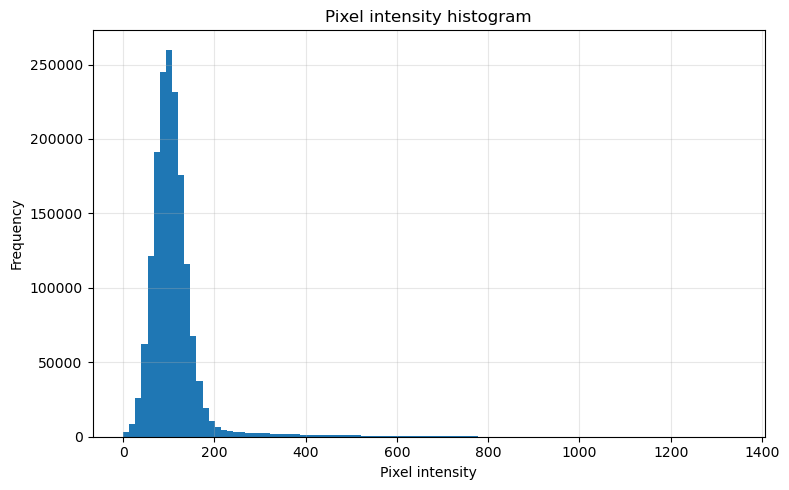

In [5]:
sim.histogram(bins=100)

In [6]:
max = np.max(frames)
min = max - 0.5*max
print(min)
print(max)

669.5484008789062
1339.0968


In [7]:
det_thresh_range = np.linspace(max-0.75*max, max, 75)
k_values = np.linspace(-0.75, 0.0, 75)
# ground truth number of fits is nparticles * nframes, since we have nparticles per frame and nframes total frames
tot_particles = simulation_config["nparticles"] * simulation_config["nframes"]
detected_peaks_range = []

for det_tr in det_thresh_range:
   print(f"Detection threshold: {det_tr:.2f}")
   detected_peaks = extract_peaks(frames, mode="detection", detection_threshold=det_tr)
   total_num_peaks = np.sum([len(peaks) for peaks in detected_peaks])
   print("Number of detected peaks:", total_num_peaks)
   detected_peaks_range.append(total_num_peaks)


Detection threshold: 334.77
Number of detected peaks: 2148
Detection threshold: 348.35
Number of detected peaks: 2127
Detection threshold: 361.92
Number of detected peaks: 2104
Detection threshold: 375.49
Number of detected peaks: 2077
Detection threshold: 389.06
Number of detected peaks: 2049
Detection threshold: 402.63
Number of detected peaks: 2023
Detection threshold: 416.21
Number of detected peaks: 1992
Detection threshold: 429.78
Number of detected peaks: 1953
Detection threshold: 443.35
Number of detected peaks: 1906
Detection threshold: 456.92
Number of detected peaks: 1867
Detection threshold: 470.49
Number of detected peaks: 1834
Detection threshold: 484.07
Number of detected peaks: 1790
Detection threshold: 497.64
Number of detected peaks: 1739
Detection threshold: 511.21
Number of detected peaks: 1689
Detection threshold: 524.78
Number of detected peaks: 1631
Detection threshold: 538.35
Number of detected peaks: 1593
Detection threshold: 551.93
Number of detected peaks: 15

In [8]:
print(len(detected_peaks_range))
print(len(det_thresh_range))

75
75


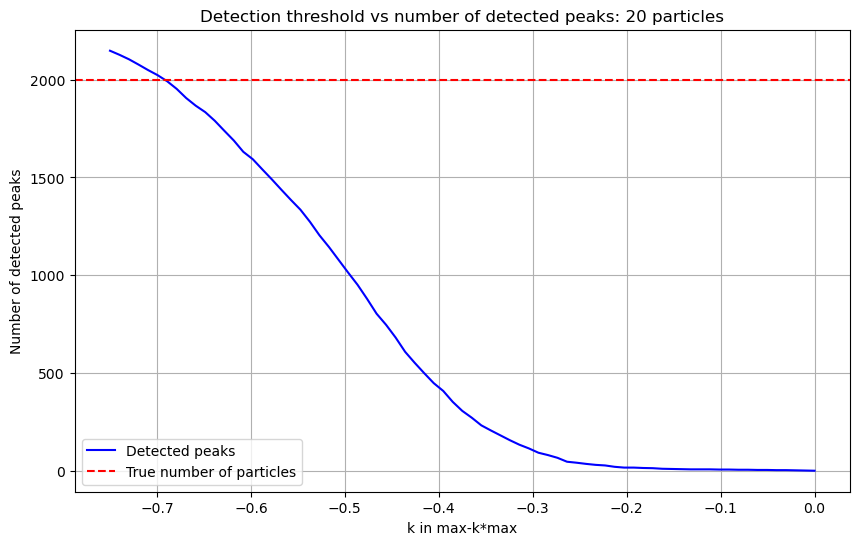

In [ ]:
# find indices where detection matches ground truth
good_idx = np.where(np.array(detected_peaks_range) == tot_particles)[0]

# group contiguous regions
good_regions = []
if len(good_idx) > 0:
    start = good_idx[0]
    for i in range(1, len(good_idx)):
        if good_idx[i] != good_idx[i-1] + 1:
            good_regions.append((start, good_idx[i-1]))
            start = good_idx[i]
    good_regions.append((start, good_idx[-1]))

plt.figure(figsize=(10, 6))
plt.plot(k_values, detected_peaks_range, label="Detected peaks", color="blue")
plt.axhline(y=tot_particles, color="red", linestyle="--", label="True number of particles")

# highlight regions + add center markers
for start, end in good_regions:
    k_left = k_values[start]
    k_right = k_values[end]
    k_center = 0.5 * (k_left + k_right)

    # shaded region
    plt.axvspan(k_left, k_right, color="green", alpha=0.2)

    # vertical line at center
    plt.axvline(k_center, color="green", linestyle="-", alpha=0.8)

    # annotate boundaries and center
    plt.text(k_left, tot_particles * 1.02, f"{k_left:.2f}", ha="center", color="green")
    plt.text(k_center, tot_particles * 1.05, f"{k_center:.2f}", ha="center", color="green", fontweight="bold")
    plt.text(k_right, tot_particles * 1.02, f"{k_right:.2f}", ha="center", color="green")

plt.xlabel("k in max-k*max")
plt.ylabel("Number of detected peaks")
plt.title(f"Detection threshold vs number of detected peaks: {simulation_config['nparticles']} particles")
plt.legend()
plt.grid()
plt.savefig(OUT_DIR / "det_thresh_1video.png")
plt.show()


## Repeat experiment to identify right value

In [10]:
# k_centers = []
# nparticles_range = np.linspace(5,45,45, dtype=int)
# nframes=1

In [11]:
# for nparticles in nparticles_range:
#     trajectories = simulate_brownian_motion(
#     nparticles=nparticles,
#     nframes=nframes,
#     nposframe=nposframe,
#     D_list=D_list,
#     dt=1.0,
#     anisotropy_ratio_range=(1.0, 1.0),
#     theta_range=(np.deg2rad(0), np.deg2rad(0)),
#     frame_size=(128, 128),
#     intensity_mean=intensity_mean,
#     intensity_std=intensity_std
#     )

#     video= trajectories_to_global_video(
#     trajectories, # still at subframe resolution
#     nframes=nframes,
#     nPosPerFrame=nposframe,
#     image_props=image_props
#     )
    
#     trajectories_GT = create_GT_trajectories(trajectories, nposframe)
#     frames = video.astype(np.float32)

#     det_thresh_range = np.linspace(intensity_mean - 1.2*intensity_std,
#                                intensity_mean + 1.2*intensity_std,
#                                100)
#     k_values = (det_thresh_range - intensity_mean) / intensity_std
#     # ground truth number of fits is nparticles * nframes, since we have nparticles per frame and nframes total frames
#     tot_particles = nparticles * nframes
#     detected_peaks_range = []

#     for det_tr in det_thresh_range:
#         print(f"Detection threshold: {det_tr:.2f}")
#         detected_peaks = track(frames, trajectories_GT, detection_threshold=det_tr, verbose_loc=False)
#         total_num_peaks = np.sum([len(peaks) for peaks in detected_peaks])
#         print("Number of detected peaks:", total_num_peaks)
#         detected_peaks_range.append(total_num_peaks)

#     # find indices where detection matches ground truth
#     good_idx = np.where(np.array(detected_peaks_range) == tot_particles)[0]

#     middle_k = None
#     if len(good_idx) > 0:
#         mid_index = good_idx[len(good_idx) // 2]   # integer middle
#         middle_k = k_values[mid_index]

#     k_centers.append(middle_k)

In [12]:
# # plot k_centers vs nparticles
# plt.figure(figsize=(10, 6))
# plt.scatter(nparticles_range, k_centers, s=60)
# plt.xlabel("Number of particles")
# plt.ylabel("Center k-value")
# plt.title("Center k-value vs number of particles")
# plt.grid()
# plt.show()

=> for now, arbitrarily selected -0.7.  
=> that is, optimal detection threshold is at $\bar{I}-0.7 \sigma_{I}$   
=> For $\bar{I}=700$ and $\sigma_{I}=300$, the optimal detection thresold is $k=700-0.7$ $\times 300 = 490$.

----

## Visual evaluation

In [13]:
# set k
k = 0.7

def detectFromFrames(frames, k, verbose=False):
    # get image min and max
    max = np.max(frames)
    min = np.min(frames)

    # detect peaks with chosen threshold
    detection_threshold = max - k * (max - min)
    if verbose:
        print(f"Chosen detection threshold: {detection_threshold:.2f}")
    
    # shape ((x,y), intensity, sigma)
    detected_peaks_metadata = extract_peaks(frames, mode="detection", detection_threshold=detection_threshold)
    # rebuild positions only
    detected_peaks = [[(int(pos[0]), int(pos[1])) for pos, _, _ in peaks] for peaks in detected_peaks_metadata]
    return detected_peaks

def visualizePeaksOnVideo(video, detected_peaks):
    # convert grayscale video to uint8 first
    video_uint8 = (255 * (video - video.min()) / (video.max() - video.min())).astype(np.uint8)

    # convert to RGB
    video_vis = np.stack([video_uint8, video_uint8, video_uint8], axis=-1).copy()

    # draw red crosses
    for frame_idx, peaks in enumerate(detected_peaks):
        for (y, x) in peaks:
            # vertical line
            video_vis[frame_idx, y-1:y+2, x, 0] = 255   # R
            video_vis[frame_idx, y-1:y+2, x, 1] = 0     # G
            video_vis[frame_idx, y-1:y+2, x, 2] = 0     # B

            # horizontal line
            video_vis[frame_idx, y, x-1:x+2, 0] = 255
            video_vis[frame_idx, y, x-1:x+2, 1] = 0
            video_vis[frame_idx, y, x-1:x+2, 2] = 0

    # animate
    animate_video(video_vis, interval=100)
    return video_vis

In [14]:
# function to get the actual number of particles on a frame, excluding the ones that have disappeared (
# i.e. that have a position outside the 128x128 background)
def getGTnparticlesPerFrame(simulation_config, trajectories_GT):
    nframes = simulation_config["nframes"]
    frame_size = simulation_config["frame_size"]
    nparticles_per_frame = []
    for frame_idx in range(nframes):
        count = 0
        for traj in trajectories_GT:
            x, y = traj.positions[frame_idx]
            if 0 <= x < frame_size[0] and 0 <= y < frame_size[1]:
                count += 1
        nparticles_per_frame.append(count)
    return nparticles_per_frame

In [ ]:
# math metric to compare: show number of detections per frame for the given threshold, with a horuizontal line for the true number of particles
def plotNumDetectionsPerFrame(detections_list, nparticles, k_range):
    plt.figure(figsize=(10, 6))
    for i, detections in enumerate(detections_list):
        detections_per_frame = [len(peaks) for peaks in detections]
    
        plt.plot(detections_per_frame, label=f"k={k_range[i]:.2f}")

    plt.plot(nparticles, color="red", linestyle="--", label="True number of particles")
    plt.xlabel("Frame index")
    plt.ylabel("Number of detected peaks")
    plt.title(f"Number of detected peaks per frame with varying k")
    plt.legend()
    plt.grid()
    plt.savefig(OUT_DIR / "det_thresh_k_range.png")
    plt.show()

In [16]:
GT_nparticles_per_frame = getGTnparticlesPerFrame(simulation_config, trajectories_GT)

In [17]:
# identified good range sits between 0.6 and 0.8: try with this refined range and superimpose curves

k_range = np.linspace(0.55, 0.75, 10)
detections_per_k = []

for k in k_range:
    detection_threshold = max - k * (max - min)
    detected_peaks = detectFromFrames(frames, k)
    detections_per_k.append(detected_peaks)


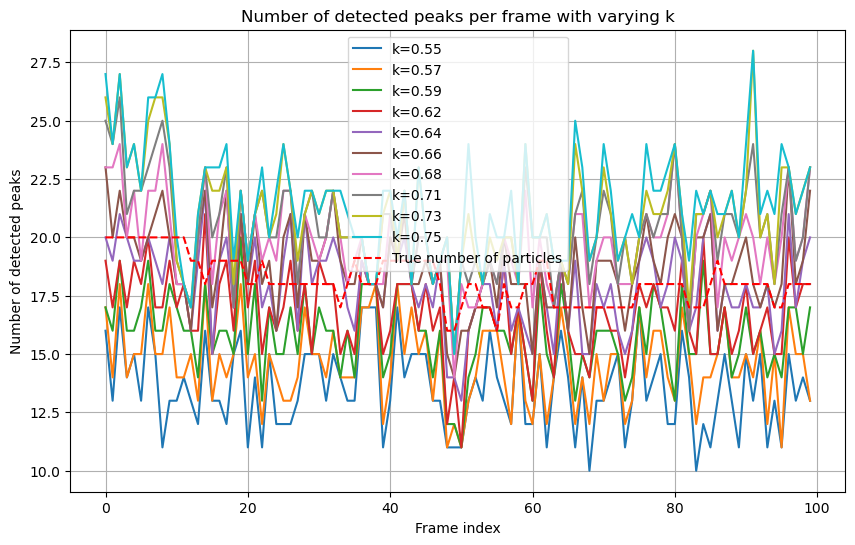

In [18]:
plotNumDetectionsPerFrame(detections_per_k, GT_nparticles_per_frame, k_range) 

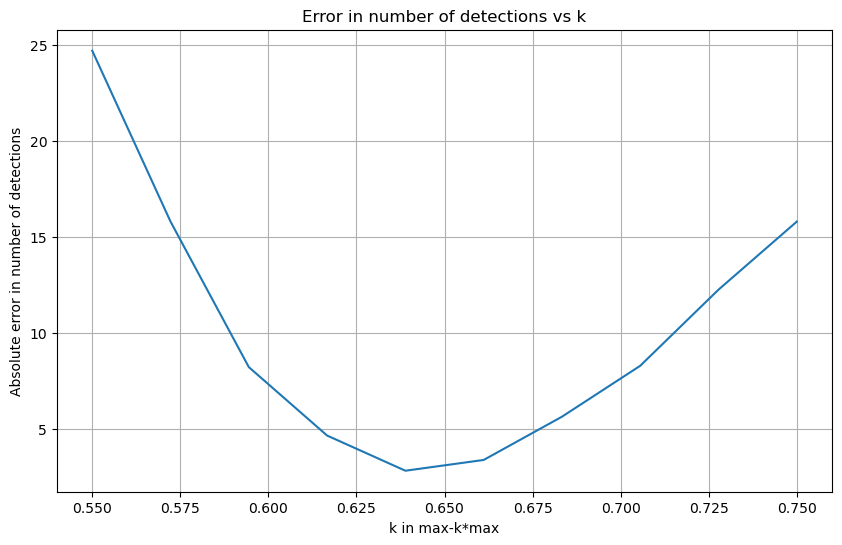

In [ ]:
# calculate best k with least squares between number of detections per frame and true number of particles, for each k, and plot the error as a function of k to find the minimum
errors = []
for detection in detections_per_k:
    detections_per_frame = [len(peaks) for peaks in detection]
    error = np.abs(np.array(detections_per_frame) - np.array(GT_nparticles_per_frame))**2
    errors.append(np.mean(error))
plt.figure(figsize=(10, 6))
plt.plot(k_range, errors)
plt.xlabel("k in max-k*max")
plt.ylabel("Absolute error in number of detections")
plt.title("Error in number of detections vs k")
plt.grid()
plt.savefig(OUT_DIR / "det_thresh_error_curve.png")
plt.show()

In [20]:
best_k = k_range[np.argmin(errors)]
print("Best error:", np.min(errors))
print("Best k:", best_k)

Best error: 2.83
Best k: 0.638888888888889


In [21]:
best_detections = detectFromFrames(frames, best_k)
print(best_detections)

[[(114, 85), (13, 52), (59, 67), (115, 50), (116, 82), (115, 16), (89, 23), (106, 112), (11, 78), (14, 88), (39, 27), (66, 33), (82, 62), (68, 32), (64, 34), (91, 77), (92, 75), (89, 70), (117, 115), (56, 54)], [(116, 83), (114, 85), (86, 73), (114, 15), (66, 31), (59, 65), (11, 76), (39, 26), (81, 63), (11, 89), (114, 50), (56, 54), (118, 113), (95, 95), (67, 34), (89, 23), (116, 51), (90, 81), (56, 52)], [(114, 85), (114, 16), (89, 23), (56, 57), (12, 77), (82, 63), (58, 62), (66, 29), (116, 50), (39, 27), (84, 89), (58, 64), (117, 82), (11, 45), (13, 90), (118, 113), (65, 33), (65, 35), (82, 78), (97, 99), (85, 86)], [(83, 82), (114, 85), (83, 86), (85, 85), (59, 64), (39, 26), (11, 76), (89, 22), (114, 16), (64, 36), (118, 50), (68, 28), (81, 62), (118, 112), (56, 57), (106, 114), (9, 48), (12, 89), (108, 114), (9, 46)], [(115, 84), (114, 16), (68, 29), (89, 22), (84, 82), (84, 80), (63, 38), (38, 25), (83, 63), (11, 87), (12, 77), (63, 36), (55, 56), (118, 51), (84, 87), (89, 103)

In [22]:
video_vis = visualizePeaksOnVideo(video, best_detections)
animate_video(video_vis, interval=100)

## Repeat full pipeline with varying number of particles for consistency check

In [23]:
nframes = 50

best_k_list = []

nparticles_range = np.linspace(5,25,20, dtype=int)

for nparticles in nparticles_range:
    sim = Simulator(
        simulation_config=simulation_config,
        image_config=image_config,
        seed=42,
    ).run()

    frames = sim.frames
    trajectories_GT = sim.trajectories_GT
    trajectories = sim.trajectories_FR

    nframes = simulation_config["nframes"]

    k_range = np.linspace(0.65, 0.75, 10)
    
    detections_per_k = []

    for k in k_range:
        detection_threshold = max - k * (max - min)
        detected_peaks = detectFromFrames(frames, k)
        detections_per_k.append(detected_peaks)
    
    errors = []

    for detection in detections_per_k:
        detections_per_frame = [len(peaks) for peaks in detection]
        error = (1/nframes) * np.abs(np.array(detections_per_frame) - getGTnparticlesPerFrame(simulation_config, trajectories_GT))**2
        errors.append(np.mean(error))

    best_k = k_range[np.argmin(errors)]
    best_k_list.append(best_k)

plt.figure(figsize=(10, 6))
plt.scatter(nparticles_range, best_k_list, s=60)
plt.xlabel("Number of particles")
plt.ylabel("Best k-value")
plt.title("Best k-value vs number of particles")
plt.grid()
plt.show()

KeyboardInterrupt: 

In [ ]:
plt.savefig(OUT_DIR / "det_thresh_mean_overall.png")

In [ ]:
k = np.mean(best_k_list)
print(f"Chosen k: {k:.2f}")

0.6894444444444445


In [ ]:
# visualize with best k
visualizePeaksOnVideo(video, detectFromFrames(frames, k, verbose=True))